# Phase 8 — Attention & Transformers: How Every Modern LLM Reads

ChatGPT, Claude, Gemini, Llama — every one of them is built on the idea in this notebook. It
fits in about four lines of code, and by the end you'll have written it yourself and proved
it matches PyTorch's own version to six decimal places.

### The problem Phase 7 left us with

An RNN reads a sentence **one word at a time**, squeezing everything it has read so far into
a single hidden state before moving on.

Think of the party game where a message is whispered down a line of people. By the fortieth
person, the start of the message is mush. That's exactly what we measured in Phase 7: in an LSTM, the
gradient from about 50 steps back had shrunk to around 0.00000000002, and at length 40 none of
the three models we tried could remember the first digit at all.

It has a second, less obvious problem: **it's slow in a way you can't fix with a bigger GPU.**
Word 50 can't be processed until word 49 is finished, which needs word 48, and so on. A GPU
is brilliant at doing thousands of things *at once*, and an RNN hands it a queue.

### The fix: let every word look at every other word directly

Forget the whisper line. Put everyone in the same room.

When the model processes the word *"it"* in *"the animal didn't cross the street because it
was too tired"*, it doesn't have to hope the meaning of *"animal"* survived nine whispers. It
simply **looks back at every word in the sentence at once**, decides which ones matter for
understanding *"it"* — mostly *"animal"* — and pulls in information from those.

That's **attention**. Two consequences:

1. **Distance stops mattering.** Word 1 is exactly as reachable from word 500 as word 499 is.
2. **Everything happens at once.** Every word does its looking-around simultaneously, which is
   precisely what GPUs are good at. This is the real reason transformers could be scaled up to
   the size of modern LLMs and RNNs couldn't.

### The vocabulary

| Term | What it actually means |
|---|---|
| token | One piece of the input — roughly a word or part of a word |
| query (Q) | What this word is **looking for** — "I'm a pronoun, who do I refer to?" |
| key (K) | What each word **advertises** about itself — "I'm a noun, an animal" |
| value (V) | What each word **hands over** if it's chosen |
| attention weights | How much each word listens to each other word. Each row adds up to 1 |
| scaled dot-product attention | The whole mechanism: match queries to keys, soften, blend the values |
| head | One independent set of Q/K/V — one "way of looking" |
| multi-head attention | Several heads side by side, each free to notice different relationships |
| positional encoding | A position stamp added to each word, because attention has no sense of order |
| mask | Blocks certain words from being looked at — future words, or padding |
| encoder layer | Attention + a small per-word network + the plumbing that keeps it stable |

## What this notebook covers
```
why RNNs hit a wall (measured) -> attention from scratch, step by step
    -> why we divide by sqrt(d) -> masks -> multi-head attention from scratch
    -> PROOF it matches nn.MultiheadAttention -> why position has to be added
    -> inside nn.TransformerEncoderLayer -> a transformer that learns to sort
```

## Section 1 — Measuring the Wall

A claim like "attention handles distance better" is cheap. Let's measure it the same way we
did in Phase 7.

We build a sequence of 100 tokens, take the model's output at the **last** position, and ask
autograd: *how much does that output depend on the **first** token?* That's the gradient
flowing back 99 steps.

- For an **LSTM**, the information has to be passed along 99 times.
- For **attention**, the last position looks at the first one directly — one step, no matter
  how far apart they are.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── HOW MUCH DOES THE LAST OUTPUT DEPEND ON THE FIRST TOKEN? ─────────────────
T, d = 100, 32                                  # 100 tokens, 32 numbers each

def gradient_reaching_each_token(model_fn):
    x = torch.randn(1, T, d, requires_grad=True)
    out = model_fn(x)                           # (1, T, d)
    out[0, -1].sum().backward()                 # 'how does the LAST output change...'
    return x.grad[0].norm(dim=1)                # '...when each INPUT token changes?'

torch.manual_seed(0)
lstm = nn.LSTM(d, d, batch_first=True)
g_lstm = gradient_reaching_each_token(lambda x: lstm(x)[0])

torch.manual_seed(0)
attn = nn.MultiheadAttention(d, num_heads=4, batch_first=True)
g_attn = gradient_reaching_each_token(lambda x: attn(x, x, x, need_weights=False)[0])

print("gradient reaching token...      LSTM         attention")
for t in (99, 90, 50, 0):
    print(f"   {t:>2} ({99 - t:>2} steps back)      {g_lstm[t]:.1e}      {g_attn[t]:.1e}")

print(f"\nfirst token vs last token:  LSTM {g_lstm[0] / g_lstm[-1]:.0e}   "
      f"attention {g_attn[0] / g_attn[-1]:.2f}")

gradient reaching token...      LSTM         attention
   99 ( 0 steps back)      6.7e-01      2.8e-01
   90 ( 9 steps back)      2.5e-03      3.0e-02
   50 (49 steps back)      1.3e-11      3.2e-02
    0 (99 steps back)      3.4e-22      4.0e-02

first token vs last token:  LSTM 5e-22   attention 0.14


Read down each column. For the LSTM, the influence shrinks at every step back until the first
token has collapsed to effectively nothing — around twenty orders of magnitude below the last.

For attention, the tokens 9, 49 and 99 steps back all have **about the same influence as each
other**. The last token scores somewhat higher only because it's also the one asking the
question, so it reaches the output by an extra direct route. Distance itself makes no difference
at all.

That isn't a tuned result or a lucky seed. It's structural: in attention every token is one
step from every other token, so there is nothing for the signal to decay through.

## Section 2 — Attention From Scratch, One Step at a Time

Here's the whole idea as a library visit.

You walk in with a **query**: *"I need something about sleepy animals."* Every book on the
shelf has a **key** — the label on its spine. You compare your query against every label and
score how well each matches. Then instead of taking just the single best book, you take a
**blend** of all of them, weighted by how well they matched — mostly the good matches, a bit
of the rest. What you actually read from each book is its **value**, its contents.

In a sentence, *every word does this at the same time*:

```
1. SCORE     compare my query against every word's key          scores  = Q @ K.T
2. SCALE     shrink the scores so softmax doesn't go extreme    scores  = scores / sqrt(d_k)
3. SOFTEN    turn scores into weights that add up to 1           weights = softmax(scores)
4. BLEND     mix everyone's values using those weights           output  = weights @ V
```

Where do Q, K and V come from? **Three separate `nn.Linear` layers applied to the same words.**
The network learns what to look for, what to advertise, and what to hand over — they start
random and are trained like any other weights.

That's the entire mechanism. Let's walk through it on a four-word sentence and check every
shape.

In [2]:
torch.manual_seed(42)

words = ["the", "cat", "sat", "down"]
d_model = 8                                    # 8 numbers describe each word
x = torch.randn(len(words), d_model)           # stand-in embeddings, one row per word

# ── WHERE Q, K AND V COME FROM: THREE LEARNED PROJECTIONS OF THE SAME WORDS ──
W_q = nn.Linear(d_model, d_model, bias=False)  # learns what to LOOK FOR
W_k = nn.Linear(d_model, d_model, bias=False)  # learns what to ADVERTISE
W_v = nn.Linear(d_model, d_model, bias=False)  # learns what to HAND OVER

Q, K, V = W_q(x), W_k(x), W_v(x)
print(f"x: {tuple(x.shape)}   Q: {tuple(Q.shape)}   K: {tuple(K.shape)}   V: {tuple(V.shape)}")

# ── STEP 1: SCORE — every word's query against every word's key ──────────────
scores = Q @ K.T                               # (4, 4): row = who's looking, column = at whom
print(f"\nstep 1  scores  {tuple(scores.shape)}  <- one score for every (word, word) pair")

# ── STEP 2: SCALE — divide by sqrt(d_k). Section 3 shows why this matters ────
scores = scores / math.sqrt(d_model)

# ── STEP 3: SOFTEN — softmax along each row, so each row adds up to 1 ────────
weights = F.softmax(scores, dim=-1)
print(f"step 3  weights {tuple(weights.shape)}  each row sums to: {weights.sum(dim=-1).round(decimals=4).tolist()}")

# ── STEP 4: BLEND — each word becomes a weighted mix of everyone's values ────
output = weights @ V                           # (4, 8): same shape as the input
print(f"step 4  output  {tuple(output.shape)}  <- same shape in as out, so layers can stack")

print("\nhow much each word listens to each other word:")
print("            " + "".join(f"{w:>7}" for w in words))
for w, row in zip(words, weights):
    print(f"  {w:>6} -> " + "".join(f"{v:7.2f}" for v in row))

x: (4, 8)   Q: (4, 8)   K: (4, 8)   V: (4, 8)

step 1  scores  (4, 4)  <- one score for every (word, word) pair
step 3  weights (4, 4)  each row sums to: [1.0, 1.0, 1.0, 1.0]
step 4  output  (4, 8)  <- same shape in as out, so layers can stack

how much each word listens to each other word:
                the    cat    sat   down
     the ->    0.33   0.22   0.19   0.26
     cat ->    0.20   0.26   0.23   0.32
     sat ->    0.36   0.25   0.26   0.13
    down ->    0.17   0.27   0.37   0.19


Every row is one word deciding how to divide its attention, and every row adds up to exactly
1. These particular weights mean nothing yet — the projections are random — but after
training, rows like *"it"* concentrate their weight on the noun they refer to.

Notice the output has **the same shape as the input**. Every word goes in as 8 numbers and
comes out as 8 numbers, now blended with context from the rest of the sentence. That's what
lets you stack dozens of these layers.

### Wrap it in a function, then check it against PyTorch

PyTorch ships an optimised version, `F.scaled_dot_product_attention`. If our four lines are
right, they should give the same answer.

In [3]:
# ── SCALED DOT-PRODUCT ATTENTION, FROM RAW TENSOR OPERATIONS ─────────────────
def scaled_dot_product_attention(q, k, v, mask=None):
    """q, k, v: (..., seq_len, d_k). mask: True where attention is NOT allowed."""
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)          # score + scale
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))        # blocked -> weight 0 after softmax
    weights = F.softmax(scores, dim=-1)                         # soften
    return weights @ v, weights                                 # blend

ours, our_weights = scaled_dot_product_attention(Q, K, V)
theirs = F.scaled_dot_product_attention(Q, K, V)

print("max difference from PyTorch's version:", (ours - theirs).abs().max().item())
print("match (to 1e-6)?", torch.allclose(ours, theirs, atol=1e-6))

max difference from PyTorch's version: 5.960464477539063e-08
match (to 1e-6)? True


## Section 3 — Why Divide by √d?

Step 2 looks like a fussy detail. It is the difference between a model that trains and one
that doesn't.

Here's the problem. A dot product adds up `d` multiplications. With more dimensions, you're
adding up more random-ish numbers, so the scores spread out further — their typical size grows
like √d. Real models use `d` of 64 to 128 per head.

Feed huge scores into softmax and it stops blending and goes **winner-takes-all**: one word
gets essentially all the weight, the rest get zero. Two bad things follow:

1. The word **can only listen to one other word**, which throws away the whole point.
2. Softmax is **flat** in that extreme region, so the gradient through it is nearly zero, and
   the attention layer stops learning. It's the vanishing-gradient problem again, arriving from
   a different direction.

Dividing by √d cancels the growth exactly and keeps scores in a sensible range at any size.

To make the effect readable, we'll measure **how many words each query is effectively listening
to** — out of 10 available.

In [4]:
torch.manual_seed(0)
n_keys = 10

def effectively_attended(weights):
    # 1 / sum(w^2): equals 10 if weight is spread evenly over 10 words, 1 if it's all on one
    return (1.0 / (weights ** 2).sum(dim=-1)).mean().item()

print(f"{'d':>5}  {'score spread':>13}   {'words listened to, UNSCALED':>28}   {'SCALED by sqrt(d)':>18}")
for d in (4, 16, 64, 256, 1024):
    q = torch.randn(2000, 1, d)
    k = torch.randn(2000, n_keys, d)
    raw = (q @ k.transpose(-2, -1)).squeeze(1)           # (2000, 10)
    unscaled = F.softmax(raw, dim=-1)
    scaled = F.softmax(raw / math.sqrt(d), dim=-1)
    print(f"{d:>5}  {raw.std().item():>13.1f}   {effectively_attended(unscaled):>28.2f}   "
          f"{effectively_attended(scaled):>18.2f}")

    d   score spread    words listened to, UNSCALED    SCALED by sqrt(d)
    4            2.0                           3.65                 6.05
   16            4.0                           1.93                 5.73
   64            8.0                           1.38                 5.66
  256           16.1                           1.17                 5.57
 1024           32.2                           1.09                 5.57


Without scaling, the score spread grows with `d` and the number of words listened to collapses
toward **1** — pure winner-takes-all. With scaling it stays put regardless of size.

This is why the paper that introduced transformers is titled *"Attention Is All You Need"* but
the mechanism is specifically called **scaled** dot-product attention. The scaling isn't
decoration.

## Section 4 — Masks: Rules About Who May Look at Whom

Sometimes a word must **not** be allowed to look at certain other words. The mechanism is the
same in every case: set the blocked scores to **−∞** before softmax. Since `e^−∞ = 0`, those
positions end up with a weight of exactly zero, and the remaining weights still add up to 1.

### Causal mask — no peeking at the future

A model that **generates** text (every chatbot) is trained to predict the next word. If word 3
could look at word 4 during training, it would just read the answer off the page — it would
score perfectly and learn nothing.

So each word may only look at **itself and earlier words**. Picture a sheet of paper sliding
down the page, covering everything below the line you're on. The result is a lower-triangular
pattern of weights.

### Padding mask — ignore the filler

Sentences in a batch have different lengths, so short ones are padded with filler tokens
(exactly as in Phase 7). Those shouldn't receive attention — they carry no meaning. A padding
mask blocks those columns.

In [5]:
torch.manual_seed(42)
seq_len = 5
q = k = v = torch.randn(1, seq_len, 8)

# ── CAUSAL MASK: True above the diagonal = 'this would be looking at the future' ──
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
print("causal mask (True = blocked):")
print(causal_mask.int())

out_causal, w_causal = scaled_dot_product_attention(q, k, v, mask=causal_mask)
print("\nattention weights with the causal mask:")
print(w_causal[0].round(decimals=2))
print("\nword 0 can only see itself, word 4 can see everything before it.")

# PyTorch's version has this built in as is_causal=True -- check we agree
theirs = F.scaled_dot_product_attention(q, k, v, is_causal=True)
print("matches F.scaled_dot_product_attention(is_causal=True)?",
      torch.allclose(out_causal, theirs, atol=1e-6))

# ── PADDING MASK: the last 2 positions are filler and must receive no attention ──
padding = torch.tensor([False, False, False, True, True])    # True = padding
_, w_pad = scaled_dot_product_attention(q, k, v, mask=padding)   # broadcasts across rows
print("\nweights with the last two positions masked as padding:")
print(w_pad[0].round(decimals=2))
print("columns 3 and 4 are zero everywhere; each row still sums to 1:",
      w_pad[0].sum(dim=-1).round(decimals=4).tolist())

causal mask (True = blocked):
tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

attention weights with the causal mask:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1500, 0.8500, 0.0000, 0.0000, 0.0000],
        [0.0200, 0.0300, 0.9500, 0.0000, 0.0000],
        [0.2700, 0.0600, 0.0200, 0.6400, 0.0000],
        [0.0000, 0.0100, 0.0000, 0.0200, 0.9700]])

word 0 can only see itself, word 4 can see everything before it.
matches F.scaled_dot_product_attention(is_causal=True)? True

weights with the last two positions masked as padding:
tensor([[0.9900, 0.0100, 0.0000, 0.0000, 0.0000],
        [0.1500, 0.8100, 0.0400, 0.0000, 0.0000],
        [0.0200, 0.0300, 0.9500, 0.0000, 0.0000],
        [0.7600, 0.1800, 0.0600, 0.0000, 0.0000],
        [0.3400, 0.5700, 0.1000, 0.0000, 0.0000]])
columns 3 and 4 are zero everywhere; each row still sums to 1: [1.0, 1.0, 1.0, 1.0, 1.0]


## Section 5 — Multi-Head Attention, From Scratch

One attention pattern means each word gets **one way of looking** at the sentence. But
language has many simultaneous relationships. In *"the tired animal didn't cross it"*, one
useful pattern links pronouns to nouns, another links adjectives to what they describe, another
tracks the verb and its object.

**Multi-head attention** runs several attention patterns side by side — like a panel of readers
each asked to look for something different, whose notes are then combined.

The clever part is that it **costs no extra computation**. Rather than running 4 full-size
attentions, we split the 32 numbers per word into 4 groups of 8, run attention separately on
each group, then glue the results back together:

```
(batch, seq, 32)  --split-->  (batch, 4 heads, seq, 8)  --attend-->  (batch, 4 heads, seq, 8)
                  --glue-->   (batch, seq, 32)          --final Linear-->  (batch, seq, 32)
```

The splitting is nothing but the `view` and `transpose` from Phase 1. That's genuinely all
multi-head attention is: reshaping, the four-line function above, and reshaping back.

In [6]:
class MyMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must split evenly across the heads"
        self.num_heads = num_heads
        self.d_head = d_model // num_heads            # e.g. 32 // 4 = 8 numbers per head

        # The three learned projections, plus one to recombine the heads at the end
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # (batch, seq, d_model) -> (batch, seq, heads, d_head) -> (batch, heads, seq, d_head)
        batch, seq, _ = x.shape
        return x.view(batch, seq, self.num_heads, self.d_head).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        # STEP A: project, then split the numbers into separate heads
        q = self.split_heads(self.q_proj(query))
        k = self.split_heads(self.k_proj(key))
        v = self.split_heads(self.v_proj(value))

        # STEP B: run our Section 2 attention on every head at once
        # (the leading batch and heads dimensions just come along for the ride)
        out, weights = scaled_dot_product_attention(q, k, v, mask)

        # STEP C: glue the heads back together: (batch, heads, seq, d_head) -> (batch, seq, d_model)
        batch, _, seq, _ = out.shape
        out = out.transpose(1, 2).reshape(batch, seq, -1)

        # STEP D: one final Linear lets the heads' findings mix together
        return self.out_proj(out), weights

torch.manual_seed(42)
mine = MyMultiHeadAttention(d_model=32, num_heads=4)
x = torch.randn(2, 6, 32)                              # batch of 2 sentences, 6 words, 32 numbers each

out, weights = mine(x, x, x)
print(f"input   : {tuple(x.shape)}")
print(f"output  : {tuple(out.shape)}       <- same shape out as in")
print(f"weights : {tuple(weights.shape)}  <- (batch, heads, seq, seq): one full pattern PER HEAD")

input   : (2, 6, 32)
output  : (2, 6, 32)       <- same shape out as in
weights : (2, 4, 6, 6)  <- (batch, heads, seq, seq): one full pattern PER HEAD


### The proof: does it match `nn.MultiheadAttention`?

This is the assignment for this phase. Writing something that *runs* proves nothing — the
shapes above would come out right even if the maths was subtly wrong.

The real test: **copy our weights into PyTorch's built-in layer**, feed both the same input, and
check the outputs agree. If they match to six decimal places, our implementation is doing
exactly what the production layer does.

One detail to handle: PyTorch stores the three Q/K/V projections **stacked into one big matrix**
(`in_proj_weight`) for speed, so we stack ours the same way before copying.

In [7]:
# ── BUILD PYTORCH'S VERSION WITH THE SAME SETTINGS ───────────────────────────
builtin = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True, dropout=0.0)

# ── COPY OUR WEIGHTS ACROSS ──────────────────────────────────────────────────
with torch.no_grad():
    # PyTorch keeps Q, K and V as one stacked matrix: rows 0-31 = Q, 32-63 = K, 64-95 = V
    builtin.in_proj_weight.copy_(torch.cat([mine.q_proj.weight, mine.k_proj.weight, mine.v_proj.weight]))
    builtin.in_proj_bias.copy_(torch.cat([mine.q_proj.bias, mine.k_proj.bias, mine.v_proj.bias]))
    builtin.out_proj.weight.copy_(mine.out_proj.weight)
    builtin.out_proj.bias.copy_(mine.out_proj.bias)

# ── RUN BOTH ON THE SAME INPUT ───────────────────────────────────────────────
their_out, their_weights = builtin(x, x, x, need_weights=True, average_attn_weights=False)
our_out, our_weights = mine(x, x, x)

print(f"{'':<24}{'ours':>16}{'nn.MultiheadAttention':>24}")
print(f"{'output shape':<24}{str(tuple(our_out.shape)):>16}{str(tuple(their_out.shape)):>24}")
print(f"{'weights shape':<24}{str(tuple(our_weights.shape)):>16}{str(tuple(their_weights.shape)):>24}")
print(f"\nlargest output difference : {(our_out - their_out).abs().max().item():.2e}")
print(f"largest weight difference : {(our_weights - their_weights).abs().max().item():.2e}")
print(f"\noutputs match (1e-6)?  {torch.allclose(our_out, their_out, atol=1e-6)}")
print(f"weights match (1e-6)?  {torch.allclose(our_weights, their_weights, atol=1e-6)}")

# ── AND WITH A CAUSAL MASK, TO BE THOROUGH ───────────────────────────────────
mask = torch.triu(torch.ones(6, 6, dtype=torch.bool), diagonal=1)
m_ours, _ = mine(x, x, x, mask=mask)
m_theirs, _ = builtin(x, x, x, attn_mask=mask, need_weights=False)
print(f"with a causal mask too?  {torch.allclose(m_ours, m_theirs, atol=1e-6)}")

                                    ours   nn.MultiheadAttention
output shape                  (2, 6, 32)              (2, 6, 32)
weights shape               (2, 4, 6, 6)            (2, 4, 6, 6)

largest output difference : 7.45e-08
largest weight difference : 4.47e-08

outputs match (1e-6)?  True
weights match (1e-6)?  True
with a causal mask too?  True


Every check passes: the outputs, the attention weights for each head, and the masked version.
The thing inside every LLM is those roughly twenty lines above — nothing hidden in the built-in
version that you haven't now written yourself.

**Why use the built-in one, then?** Speed. It uses fused kernels (including FlashAttention-style
implementations) that are much faster and lighter on memory for long sequences. Understand it
with yours; ship with theirs.

## Section 6 — Attention Can't See Word Order

This is the most surprising property of attention, and it's worth *watching* rather than taking
on trust.

Look back at the four steps. Score, scale, soften, blend — none of them uses a word's
**position**. Every word compares itself with every other word, and the result doesn't depend
on where anyone is standing.

That means attention treats a sentence as a **bag of words**. *"Dog bites man"* and *"man bites
dog"* contain exactly the same words, so attention alone produces exactly the same set of
outputs — just in a shuffled order. For language, that's a disaster.

Let's prove it: shuffle the input, and check whether the output is simply the original output,
shuffled the same way.

In [8]:
torch.manual_seed(0)
layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, dropout=0.0, batch_first=True).eval()

sentence = torch.randn(1, 6, 32)                      # 6 "words"
shuffle = torch.tensor([3, 0, 5, 1, 4, 2])            # a new word order

with torch.no_grad():
    out_original = layer(sentence)
    out_shuffled_input = layer(sentence[:, shuffle])

# If attention ignores order, shuffling the input just shuffles the output the same way
print("output of shuffled input == shuffled output of original input?",
      torch.allclose(out_shuffled_input, out_original[:, shuffle], atol=1e-5))
print("\nSame words -> same results, just rearranged. The layer has no idea what order they were in.")

output of shuffled input == shuffled output of original input? True

Same words -> same results, just rearranged. The layer has no idea what order they were in.


### The fix: stamp each word with its position

Since attention can't sense order, we **add** the order in before attention ever sees the words:
each position gets its own fixed pattern of numbers, which is added to the word's embedding.
Now *"dog"* at position 0 and *"dog"* at position 2 are different inputs.

The original transformer used a pattern built from sine and cosine waves of different speeds.
Think of it like a clock: the second hand, minute hand and hour hand move at different rates,
and together they give every moment a unique reading. Fast waves distinguish neighbouring
positions; slow waves distinguish distant ones.

Many newer models *learn* their position patterns, or use variants like RoPE, but the purpose is
identical: **give attention something that differs by position.**

with positional encoding, is it still just a shuffle? False
-> No. Order now changes the result, which is exactly what we wanted.


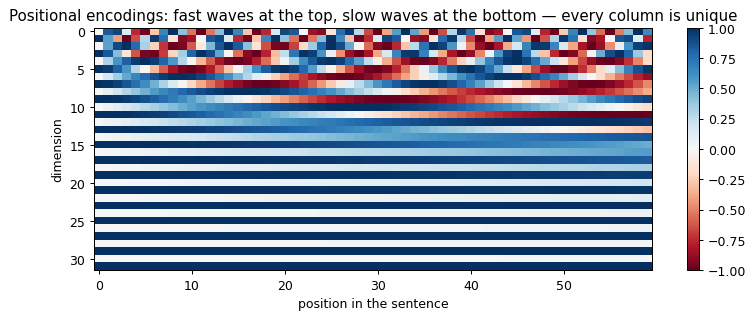

In [9]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)                         # (max_len, 1)
        # each pair of dimensions gets a wave at a different speed, fast to slow
        speed = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * speed)                             # even dims: sine
        pe[:, 1::2] = torch.cos(position * speed)                             # odd dims: cosine
        # register_buffer: saved with the model and moved by .to(device), but NOT trained
        self.register_buffer("pe", pe)

    def forward(self, x):                                                     # x: (batch, seq, d_model)
        return x + self.pe[: x.size(1)]                                       # add a position stamp to each word

pos_enc = SinusoidalPositionalEncoding(d_model=32)

# ── WHAT THE STAMPS LOOK LIKE ────────────────────────────────────────────────
plt.figure(figsize=(10, 3.5))
plt.imshow(pos_enc.pe[:60].T, aspect="auto", cmap="RdBu")
plt.xlabel("position in the sentence"); plt.ylabel("dimension")
plt.title("Positional encodings: fast waves at the top, slow waves at the bottom — every column is unique")
plt.colorbar(); plt.show()

# ── DOES IT FIX THE SHUFFLING PROBLEM? ───────────────────────────────────────
with torch.no_grad():
    out_original = layer(pos_enc(sentence))
    out_shuffled_input = layer(pos_enc(sentence[:, shuffle]))
print("with positional encoding, is it still just a shuffle?",
      torch.allclose(out_shuffled_input, out_original[:, shuffle], atol=1e-5))
print("-> No. Order now changes the result, which is exactly what we wanted.")

## Section 7 — Inside `nn.TransformerEncoderLayer`

Attention is the headline, but a transformer layer wraps it with three supporting pieces. Each
exists for a plain reason:

```
input ─┬─> multi-head attention ─> + ─> LayerNorm ─┬─> feed-forward ─> + ─> LayerNorm ─> output
       └──────────────────────────┘                └───────────────────┘
          (residual connection)                       (residual connection)
```

| Piece | What it does, in plain terms |
|---|---|
| **Multi-head attention** | Words **talk to each other** and gather context |
| **Feed-forward network** | Each word then **thinks on its own** about what it gathered — the same small MLP applied to every position |
| **Residual connection** (`+`) | Keep the original and **add** the new information on top, rather than replacing it. Gradients get a clean shortcut straight through, which is what makes 100-layer stacks trainable |
| **LayerNorm** | Rescales the numbers back into a sensible range after each step, so they don't drift huge or tiny as layers stack up |

A full transformer is just this layer, repeated. GPT-3 repeats it 96 times.

### Two settings that catch people

**`batch_first=True`** — for historical reasons, PyTorch's transformer layers default to
`(seq, batch, d_model)`, the opposite of almost everything else. Forget this flag and your batch
and sequence dimensions get silently swapped. **Always set it.**

**`src_key_padding_mask`** — how you pass the padding mask from Section 4. Shape
`(batch, seq)`, `True` meaning "this is padding, ignore it".

In [10]:
torch.manual_seed(0)
encoder_layer = nn.TransformerEncoderLayer(
    d_model=64,             # numbers per word
    nhead=4,                # attention heads (64 splits into 4 x 16)
    dim_feedforward=256,    # the per-word MLP widens to this, then narrows back to 64
    dropout=0.1,
    batch_first=True,       # (batch, seq, d_model) -- ALWAYS set this
)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)    # the same layer, stacked 3 times

print(encoder_layer)

n_attn = sum(p.numel() for p in encoder_layer.self_attn.parameters())
n_ffn = sum(p.numel() for n, p in encoder_layer.named_parameters() if n.startswith("linear"))
n_total = sum(p.numel() for p in encoder_layer.parameters())
print(f"\nparameters per layer: {n_total:,}")
print(f"  attention    : {n_attn:,} ({100 * n_attn / n_total:.0f}%)")
print(f"  feed-forward : {n_ffn:,} ({100 * n_ffn / n_total:.0f}%)  <- most of the weights live here, not in attention")

# ── PADDING MASK IN PRACTICE: two sentences, the second is 2 words shorter ───
batch = torch.randn(2, 7, 64)
padding_mask = torch.tensor([[False] * 7,
                             [False] * 5 + [True] * 2])         # True = filler, ignore it
encoder.eval()
with torch.no_grad():
    out = encoder(batch, src_key_padding_mask=padding_mask)
print(f"\nencoder output: {tuple(out.shape)}  <- (batch, seq, d_model), shape unchanged through all 3 layers")

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear1): Linear(in_features=64, out_features=256, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=256, out_features=64, bias=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

parameters per layer: 49,984
  attention    : 16,640 (33%)
  feed-forward : 33,088 (66%)  <- most of the weights live here, not in attention

encoder output: (2, 7, 64)  <- (batch, seq, d_model), shape unchanged through all 3 layers


That parameter split surprises most people: **roughly two thirds of a transformer's weights are
in the humble feed-forward network**, not in attention. Attention decides *where information
flows*; the feed-forward layers do much of the actual *storing and transforming*. In large
language models, a lot of what the model "knows" is thought to live in those feed-forward
weights.

## Section 8 — A Transformer That Learns to Sort

Time to train one. The task: **given 8 random digits, output them in sorted order.**

```
input : 7 2 9 2 0 5 3 8
output: 0 2 2 3 5 7 8 9
```

It's a good toy task for three reasons. It's instant to generate endless training data. It
genuinely requires looking at **every** input digit to produce **each** output — you can't know
what goes in position 3 without seeing all the others. And there's no way to fake it with
simple word statistics.

We'll train it **twice**: once with positional encoding, once without. Section 6 said attention
alone can't know positions. This is where we find out whether that matters in practice.

This model is tiny, so it trains in seconds on the CPU — the effort of shipping small batches to
a GPU isn't worth it at this size.

In [11]:
device = "cpu"    # a ~70k-parameter model: the CPU handles it comfortably
VOCAB, SEQ_LEN = 10, 8

def make_batch(n):
    x = torch.randint(0, VOCAB, (n, SEQ_LEN))        # random digits
    return x, x.sort(dim=1).values                    # the answer: the same digits, sorted

class DigitSorter(nn.Module):
    def __init__(self, use_positions, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(VOCAB, d_model)                     # digit -> 64 numbers
        # the ONLY difference between the two models we'll train:
        self.positions = SinusoidalPositionalEncoding(d_model) if use_positions else nn.Identity()
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128,
                                           dropout=0.0, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.head = nn.Linear(d_model, VOCAB)                         # 64 numbers -> 10 digit scores

    def forward(self, x):
        h = self.embed(x) * math.sqrt(self.d_model)   # scale embeddings up to match the position stamps
        h = self.positions(h)
        h = self.encoder(h)
        return self.head(h)                            # (batch, seq, 10): a digit guess for EVERY position

def train_sorter(use_positions, steps=3000):
    torch.manual_seed(0)
    model = DigitSorter(use_positions).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for step in range(1, steps + 1):
        x, y = make_batch(128)
        optimizer.zero_grad()
        logits = model(x)                                        # (128, 8, 10)
        # CrossEntropyLoss wants (N, classes): flatten every position of every sequence into one list
        loss = loss_fn(logits.reshape(-1, VOCAB), y.reshape(-1))
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if step % 1000 == 0:
            print(f"  positions={use_positions!s:<5} step {step}: loss {loss.item():.3f}")
    return model, history

print("training WITH positional encoding:")
model_pos, hist_pos = train_sorter(use_positions=True)
print("training WITHOUT positional encoding:")
model_nopos, hist_nopos = train_sorter(use_positions=False)

training WITH positional encoding:
  positions=True  step 1000: loss 0.049
  positions=True  step 2000: loss 0.005
  positions=True  step 3000: loss 0.006
training WITHOUT positional encoding:
  positions=False step 1000: loss 1.623
  positions=False step 2000: loss 1.663
  positions=False step 3000: loss 1.650


                                  digits right    whole sequence right
with positional encoding                99.9%                  99.6%
WITHOUT positional encoding             30.2%                   0.0%

some examples:
  input   [2, 9, 2, 0, 0, 2, 6, 7]
  correct [0, 0, 2, 2, 2, 6, 7, 9]
  with PE [0, 0, 2, 2, 2, 6, 7, 9]   ✓
  no PE   [2, 2, 2, 2, 2, 2, 2, 2]   ✗

  input   [9, 4, 1, 1, 6, 1, 2, 9]
  correct [1, 1, 1, 2, 4, 6, 9, 9]
  with PE [1, 1, 1, 2, 4, 6, 9, 9]   ✓
  no PE   [1, 1, 1, 1, 1, 1, 1, 1]   ✗

  input   [4, 1, 3, 0, 0, 6, 5, 7]
  correct [0, 0, 1, 3, 4, 5, 6, 7]
  with PE [0, 0, 1, 3, 4, 5, 6, 7]   ✓
  no PE   [0, 0, 0, 0, 0, 0, 0, 0]   ✗

  input   [9, 2, 1, 6, 0, 6, 6, 5]
  correct [0, 1, 2, 5, 6, 6, 6, 9]
  with PE [0, 1, 2, 5, 6, 6, 6, 9]   ✓
  no PE   [6, 6, 6, 6, 6, 6, 6, 6]   ✗



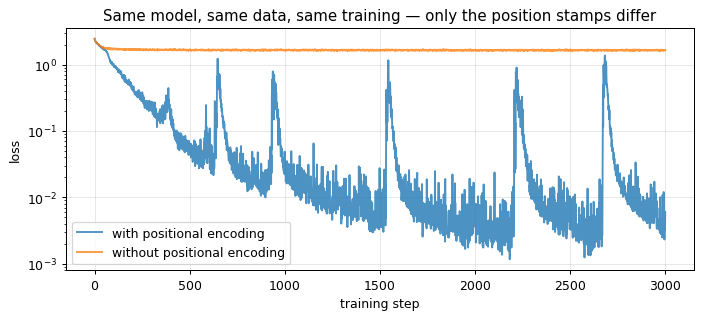

In [12]:
# ── THE HONEST TEST: FRESH SEQUENCES THE MODELS HAVE NEVER SEEN ──────────────
torch.manual_seed(123)
x_test, y_test = make_batch(5000)

def evaluate(model):
    model.eval()
    with torch.no_grad():
        predictions = model(x_test).argmax(dim=-1)
    digit_acc = (predictions == y_test).float().mean().item()          # individual digits right
    sequence_acc = (predictions == y_test).all(dim=1).float().mean().item()   # ALL 8 right
    return predictions, digit_acc, sequence_acc

pred_pos, digit_pos, seq_pos = evaluate(model_pos)
pred_nopos, digit_nopos, seq_nopos = evaluate(model_nopos)

print(f"{'':<32}{'digits right':>14}{'whole sequence right':>24}")
print(f"{'with positional encoding':<32}{digit_pos:>13.1%}{seq_pos:>23.1%}")
print(f"{'WITHOUT positional encoding':<32}{digit_nopos:>13.1%}{seq_nopos:>23.1%}")

print("\nsome examples:")
for i in range(4):
    print(f"  input   {x_test[i].tolist()}")
    print(f"  correct {y_test[i].tolist()}")
    print(f"  with PE {pred_pos[i].tolist()}   {'✓' if torch.equal(pred_pos[i], y_test[i]) else '✗'}")
    print(f"  no PE   {pred_nopos[i].tolist()}   {'✓' if torch.equal(pred_nopos[i], y_test[i]) else '✗'}\n")

plt.figure(figsize=(9, 3.5))
plt.plot(hist_pos, label="with positional encoding", alpha=0.8)
plt.plot(hist_nopos, label="without positional encoding", alpha=0.8)
plt.xlabel("training step"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Same model, same data, same training — only the position stamps differ")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

With positional encoding, the model sorts nearly every sequence perfectly. Without it, it gets
**essentially none** of them fully right — even though every other detail is identical.

Now look closely at what the no-PE model actually outputs, because it's more interesting than
random junk: **it writes the same digit in every single slot** — and that digit is the one that
appears *most often* in the input. `[2, 9, 2, 0, 0, 2, 6, 7]` has three 2s, so it answers
`[2, 2, 2, 2, 2, 2, 2, 2]`.

That's not a bug. It's the smartest possible strategy for a model that **can't tell which slot
it's filling**. If you had to fill in slot 3 of a sorted list without knowing it was slot 3, your
best bet is whichever digit is most common, since that has the highest chance of being right
wherever you are. The model worked that out on its own. It scores around 30% of individual digits
that way, and getting all eight right by that strategy is essentially impossible.

That's Section 6's proof, now showing up as a training result: **attention without positions is
blind to order, and order is the whole task.**

## Phase 8 Summary

### Cheat sheet
```
The whole mechanism -- scaled dot-product attention:
  scores  = Q @ K.transpose(-2, -1) / sqrt(d_k)     # SCORE every pair, then SCALE
  scores  = scores.masked_fill(mask, -inf)           # (optional) block some pairs
  weights = softmax(scores, dim=-1)                  # SOFTEN: each row sums to 1
  output  = weights @ V                              # BLEND everyone's values
  Q, K, V = three separate nn.Linear projections of the same input

Built-ins:
  F.scaled_dot_product_attention(q, k, v, is_causal=True)   # fast, fused kernels
  nn.MultiheadAttention(d_model, num_heads, batch_first=True)
  nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, batch_first=True)
  nn.TransformerEncoder(layer, num_layers)
  encoder(x, src_key_padding_mask=pad)   # pad: (batch, seq), True = ignore

Masks -- set blocked scores to -inf so they get weight 0:
  causal  : torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)   # no peeking ahead
  padding : True where the token is filler

Multi-head = split, attend, glue:
  (B, L, d) -> view(B, L, h, d/h).transpose(1, 2) -> attention -> transpose back -> out_proj
  nn.MultiheadAttention stores Q/K/V stacked in one in_proj_weight

Positional encoding -- attention is blind to order without it:
  x = embedding(tokens) * sqrt(d_model) + positional_encoding
  register_buffer("pe", pe)   # saved and moved with the model, not trained

Inside an encoder layer:
  attention (words talk) + feed-forward (each word thinks) + residual (+) + LayerNorm
  about 2/3 of the parameters are in the feed-forward part

What we measured in this notebook:
  gradient from token 0 to the last output : LSTM collapses to ~nothing, attention stays comparable
  unscaled softmax at large d               : collapses to listening to ~1 word
  our multi-head attention vs PyTorch's     : identical to 1e-6, with and without a mask
  sorting digits WITH vs WITHOUT positions  : near-perfect vs essentially zero whole sequences
```

### The five things worth memorising

1. **Attention lets every word look at every other word directly.** Distance stops mattering, and
   it all runs in parallel — the real reason transformers scaled and RNNs didn't.
2. **Query = what I'm looking for, key = what I advertise, value = what I hand over.** Three
   learned `Linear` layers.
3. **Divide by √d_k** or softmax goes winner-takes-all and learning stalls.
4. **Attention alone can't see word order.** Positional encoding isn't optional.
5. **Always `batch_first=True`.** PyTorch's transformer layers default to the opposite.

### Test yourself before moving on

1. In `scaled_dot_product_attention`, remove the `/ math.sqrt(d_k)`. Does the digit sorter still
   train? Try it with `d_model=256`.
2. Change `SEQ_LEN` to 16. Does the sorter still work? Does it need more steps?
3. Why does the causal mask use `-inf` rather than just `0` for blocked scores? *(Hint: what is
   `softmax` of a score of 0?)*
4. With 8 heads and `d_model=64`, what is `d_head`? What goes wrong with `d_model=60`?

### Up next — Phase 9: Practical NLP with Pretrained Transformers
Real text, real tokenizers, and fine-tuning a pretrained language model (DistilBERT) on the same
IMDB reviews the Phase 7 LSTM learned from — so we can measure exactly what pretraining buys, and
whether it can finally beat the humble bag of words that out-scored the LSTM (85.7% to 83.9%).